In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Superstore.csv')

In [2]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month

In [3]:
category_sales = df.groupby('Category')['Sales'].sum()
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
monthly_sales = df.groupby('Month')['Sales'].sum()
category_profit = df.groupby('Category')['Profit'].sum()
top_10_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

In [4]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print("="*50)
print("KEY PERFORMANCE INDICATORS (KPIs)")
print("="*50)
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

KEY PERFORMANCE INDICATORS (KPIs)
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%


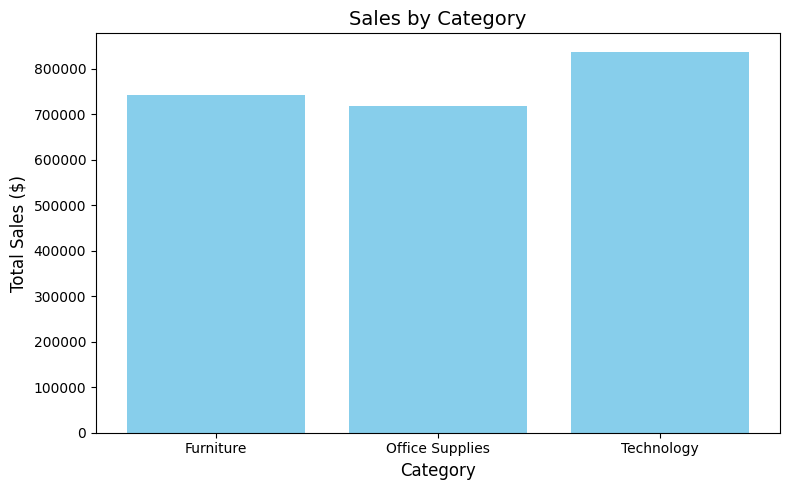

In [5]:
plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values, color='skyblue')
plt.title('Sales by Category', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.show()

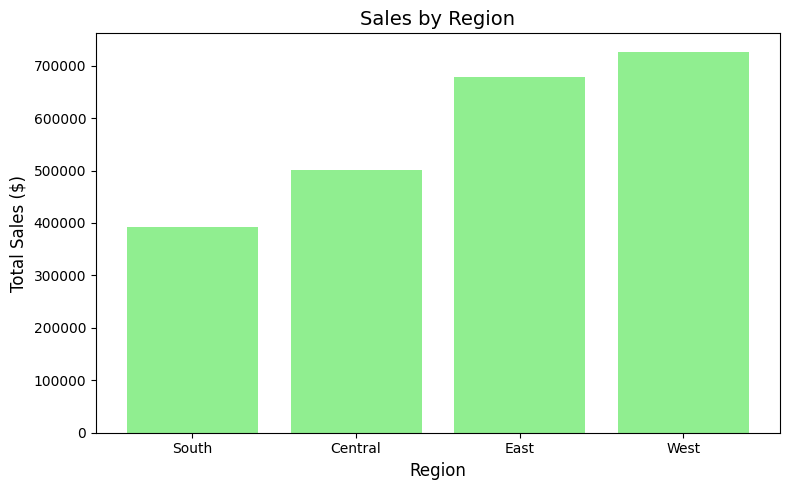

In [6]:
plt.figure(figsize=(8,5))
plt.bar(region_sales.index, region_sales.values, color='lightgreen')
plt.title('Sales by Region', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.show()

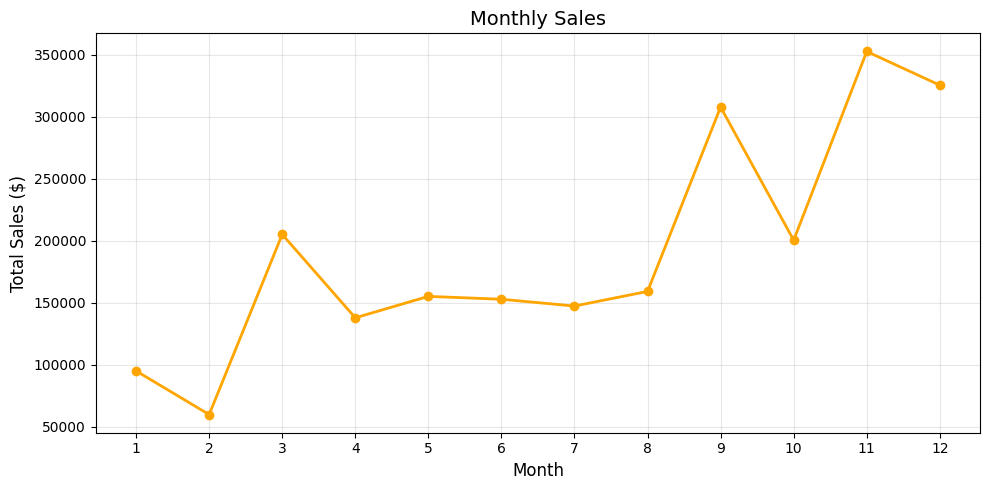

In [7]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2, color='orange')
plt.title('Monthly Sales', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(range(1,13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

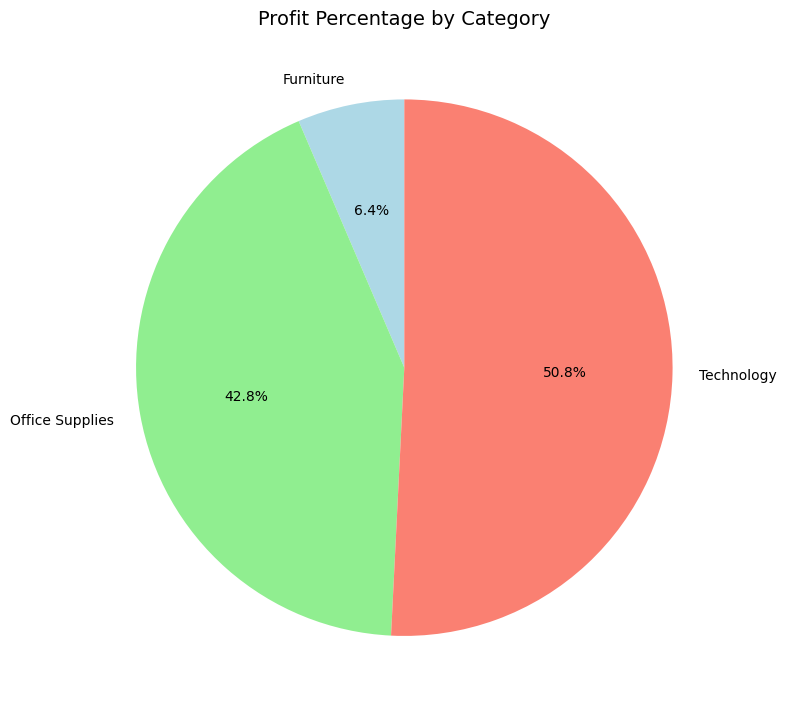

In [8]:
plt.figure(figsize=(8,8))
plt.pie(category_profit.values, labels=category_profit.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'salmon'])
plt.title('Profit Percentage by Category', fontsize=14)
plt.tight_layout()
plt.show()

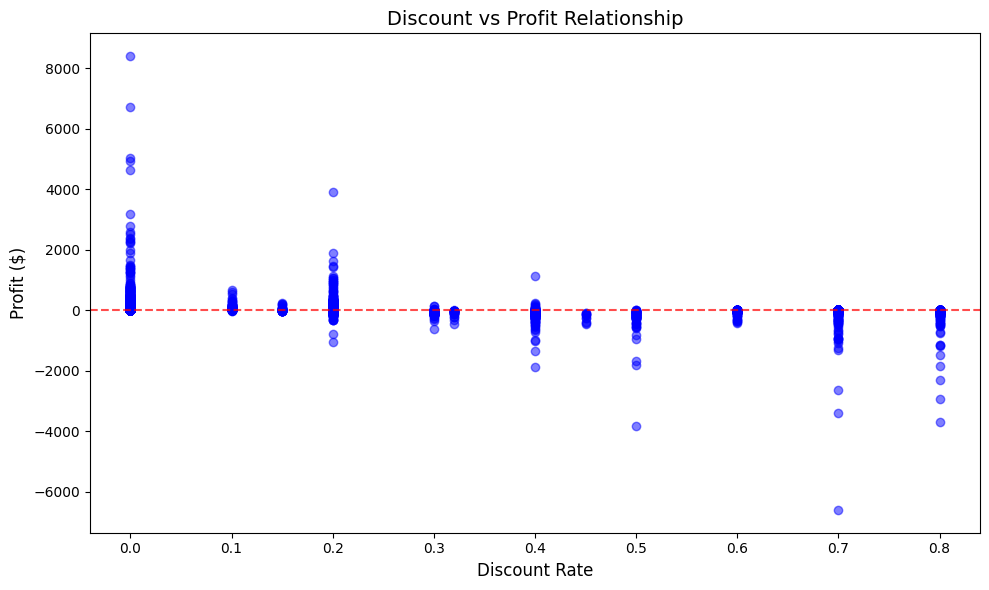

In [9]:
plt.figure(figsize=(10,6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.5, c='blue')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.title('Discount vs Profit Relationship', fontsize=14)
plt.xlabel('Discount Rate', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.tight_layout()
plt.show()

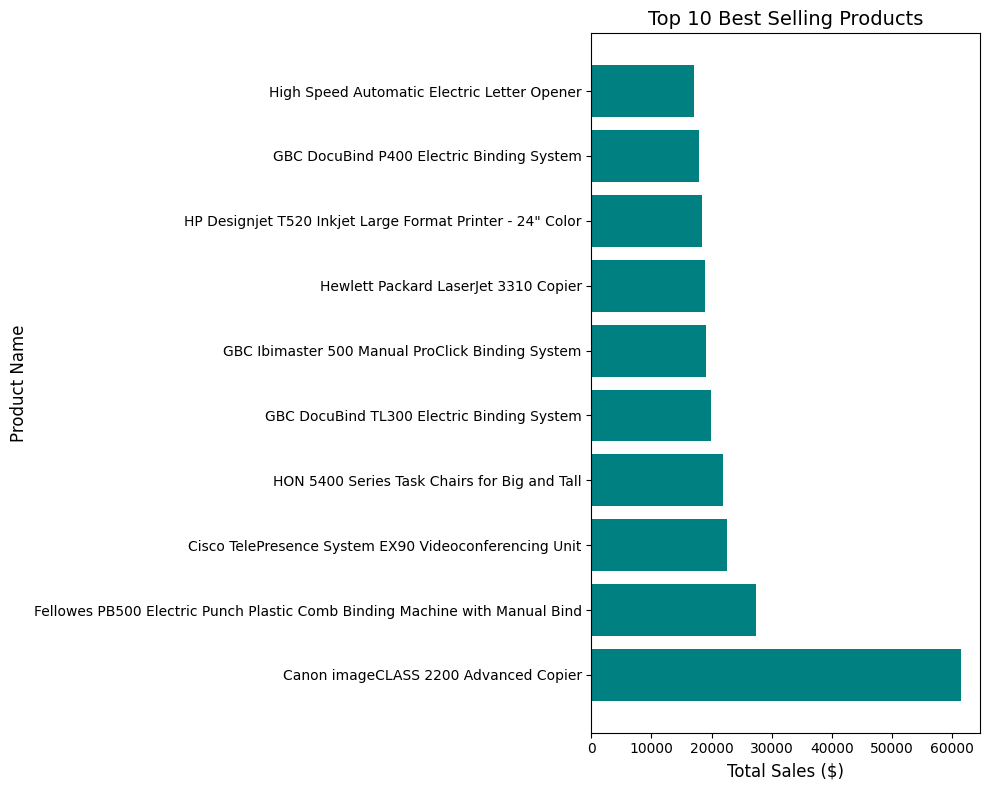

In [10]:
plt.figure(figsize=(10, 8))
plt.barh(top_10_products.index, top_10_products.values, color='teal')
plt.title('Top 10 Best Selling Products', fontsize=14)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()

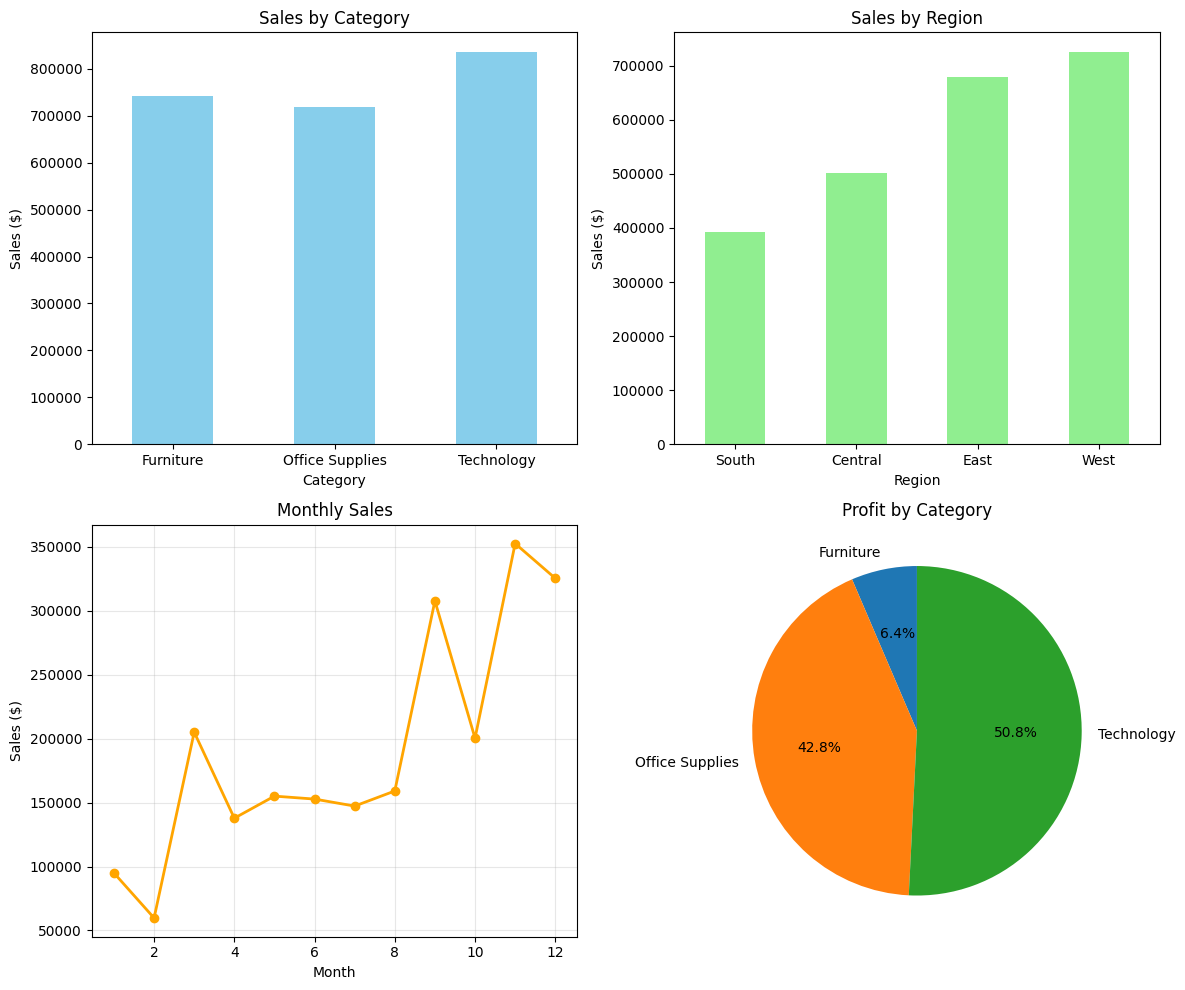

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Sales by Category
category_sales.plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Sales by Category', fontsize=12)
axes[0,0].set_ylabel('Sales ($)', fontsize=10)
axes[0,0].tick_params(axis='x', rotation=0)

# 2. Sales by Region
region_sales.plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Sales by Region', fontsize=12)
axes[0,1].set_ylabel('Sales ($)', fontsize=10)
axes[0,1].tick_params(axis='x', rotation=0)

# 3. Monthly Sales
monthly_sales.plot(kind='line', marker='o', ax=axes[1,0], color='orange', linewidth=2)
axes[1,0].set_title('Monthly Sales', fontsize=12)
axes[1,0].set_ylabel('Sales ($)', fontsize=10)
axes[1,0].set_xlabel('Month', fontsize=10)
axes[1,0].grid(True, alpha=0.3)

# 4. Profit by Category
category_profit.plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Profit by Category', fontsize=12)
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()